# Seattle House Price Prediction

Professional regression case study predicting Seattle property sale prices from bedrooms, bathrooms, interior size, lot size, and ZIP code.

**Goal:** build a reproducible, leakage-aware workflow with data validation, cleaning, feature engineering, EDA, statistical testing, model comparison, residual diagnostics, uncertainty analysis, and prediction export.

**Target:** `price` in US dollars. **Useful fact:** `1 acre = 43,560 sqft`.


## 1. Imports and Data Loading

This section sets the environment, fixed random seed, and source files. Reproducibility is important because a portfolio notebook should produce the same results when re-run.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import skew
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE=42
ACRE_TO_SQFT=43560.0
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,6)

df_train_raw=pd.read_csv('train.csv')
df_test_raw=pd.read_csv('test.csv')
print('Train shape:', df_train_raw.shape)
print('Test shape:', df_test_raw.shape)

Train shape: (2016, 8)
Test shape: (505, 8)


### Quick Inspection and Validation

The first decision is whether the data is structurally usable. We check schema, missing values, duplicate rows, positive prices/sizes, and expected units. The result guides cleaning decisions.

In [2]:
display(df_train_raw.head())
display(df_test_raw.head())
print('Missing values in train:')
print(df_train_raw.isna().sum())
print('Missing values in test:')
print(df_test_raw.isna().sum())

def validation_summary(df,name):
    return pd.Series({'rows':len(df),'columns':df.shape[1],'duplicate_rows':df.duplicated().sum(),'missing_lot_size':df['lot_size'].isna().sum(),'missing_lot_size_units':df['lot_size_units'].isna().sum(),'non_positive_price':(df['price']<=0).sum(),'non_positive_size':(df['size']<=0).sum(),'size_units':', '.join(sorted(df['size_units'].dropna().astype(str).unique())),'lot_size_units':', '.join(sorted(df['lot_size_units'].dropna().astype(str).unique()))},name=name)
validation=pd.concat([validation_summary(df_train_raw,'train'),validation_summary(df_test_raw,'test')],axis=1)
display(validation)
assert (df_train_raw['price']>0).all()
assert (df_test_raw['price']>0).all()
assert set(df_train_raw['size_units'].dropna().unique())=={'sqft'}
assert set(df_test_raw['size_units'].dropna().unique())=={'sqft'}

,beds,baths,size,size_units,lot_size,lot_size_units,zip_code,price
0,3,2.5,2590.0,sqft,6000.00,sqft,98144,795000.0
1,4,2.0,2240.0,sqft,0.31,acre,98106,915000.0
2,4,3.0,2040.0,sqft,3783.00,sqft,98107,950000.0
3,4,3.0,3800.0,sqft,5175.00,sqft,98199,1950000.0
4,2,2.0,1042.0,sqft,NaN,NaN,98102,950000.0


,beds,baths,size,size_units,lot_size,lot_size_units,zip_code,price
0,3,3.0,2850.0,sqft,4200.00,sqft,98119,1175000.0
1,4,5.0,3040.0,sqft,5002.00,sqft,98106,1057500.0
2,3,1.0,1290.0,sqft,6048.00,sqft,98125,799000.0
3,3,2.0,2360.0,sqft,0.28,acre,98188,565000.0
4,3,3.5,1942.0,sqft,1603.00,sqft,98107,1187000.0


Missing values in train:
beds                0
baths               0
size                0
size_units          0
lot_size          347
lot_size_units    347
zip_code            0
price               0
dtype: int64
Missing values in test:
beds               0
baths              0
size               0
size_units         0
lot_size          77
lot_size_units    77
zip_code           0
price              0
dtype: int64


,train,test
rows,2016,505
columns,8,8
duplicate_rows,9,1
missing_lot_size,347,77
missing_lot_size_units,347,77
non_positive_price,0,0
non_positive_size,0,0
size_units,sqft,sqft
lot_size_units,"acre, sqft","acre, sqft"


**Interpretation and next decision:** the data is usable, but `lot_size` and `lot_size_units` need careful cleaning because missing values and mixed units would distort feature engineering.

## 2. Data Cleaning

Lot sizes are standardized before imputation. This is important: imputing before converting acres to square feet would mix incompatible units and produce an invalid median. The imputation value is learned from the training data only to avoid test leakage.

In [3]:
df_train=df_train_raw.copy(); df_test=df_test_raw.copy()
train_lot_unit_mode=df_train['lot_size_units'].mode()[0]
for df in [df_train,df_test]:
    df['lot_size_units']=df['lot_size_units'].fillna(train_lot_unit_mode)
    acre=df['lot_size_units'].eq('acre')
    df.loc[acre,'lot_size']=df.loc[acre,'lot_size']*ACRE_TO_SQFT
    df['lot_size_units']='sqft'
train_median_lot_sqft=df_train['lot_size'].median()
for df in [df_train,df_test]:
    df['lot_size']=df['lot_size'].fillna(train_median_lot_sqft)
print('Training median lot size after conversion:', f'{train_median_lot_sqft:,.0f} sqft')
print(df_train.isna().sum())
print(df_test.isna().sum())

Training median lot size after conversion: 5,000 sqft
beds              0
baths             0
size              0
size_units        0
lot_size          0
lot_size_units    0
zip_code          0
price             0
dtype: int64
beds              0
baths             0
size              0
size_units        0
lot_size          0
lot_size_units    0
zip_code          0
price             0
dtype: int64


**Interpretation and next decision:** the datasets now have consistent land-area units and no missing values, so feature engineering can safely use lot-size calculations.

## 3. Feature Engineering

Real-estate prices depend on ratios and interactions, not only raw fields. The engineered features capture house-land interaction, layout balance, land per bedroom, bathrooms per bedroom, total rooms, and average room size.

In [4]:
def add_features(df):
    df=df.copy(); beds_safe=df['beds'].replace(0,1); rooms_safe=(df['beds']+df['baths']).replace(0,1)
    df['size_lot_interaction']=df['size']*df['lot_size']
    df['beds_per_bath']=df['beds']/(df['baths']+0.5)
    df['lot_per_bed']=df['lot_size']/beds_safe
    df['bath_per_bed']=df['baths']/beds_safe
    df['total_rooms']=df['beds']+df['baths']
    df['size_per_room']=df['size']/rooms_safe
    return df

df_train=add_features(df_train); df_test=add_features(df_test)
numeric_cols=['beds','baths','size','lot_size','price','size_lot_interaction','beds_per_bath','lot_per_bed','bath_per_bed','total_rooms','size_per_room']
display(df_train[numeric_cols].head())

,beds,baths,size,lot_size,price,size_lot_interaction,beds_per_bath,lot_per_bed,bath_per_bed,total_rooms,size_per_room
0,3,2.5,2590.0,6000.0,795000.0,15540000.0,1.000000,2000.00,0.833333,5.5,470.909091
1,4,2.0,2240.0,13503.6,915000.0,30248064.0,1.600000,3375.90,0.500000,6.0,373.333333
2,4,3.0,2040.0,3783.0,950000.0,7717320.0,1.142857,945.75,0.750000,7.0,291.428571
3,4,3.0,3800.0,5175.0,1950000.0,19665000.0,1.142857,1293.75,0.750000,7.0,542.857143
4,2,2.0,1042.0,5000.0,950000.0,5210000.0,0.800000,2500.00,1.000000,4.0,260.500000


**Interpretation and next decision:** these features give models more ways to represent property quality and density. The next step is EDA to decide transformations and model types.

## 4. Exploratory Data Analysis

EDA is used to drive decisions: transformations, model choice, and whether statistical tests support visible patterns.

### 4.1 Distributions and Skewness

These plots show whether features are symmetric or dominated by outliers. Housing data usually has long right tails, especially for price, lot size, and interaction terms. Strong skewness motivates log transformations for linear models.

Skewed features with |skew| > 0.75:


lot_per_bed             38.028867
lot_size                37.686745
size_lot_interaction    23.735479
price                   16.927871
size                     1.803155
size_per_room            1.385660
beds                     1.333325
baths                    1.227057
bath_per_bed             1.169006
beds_per_bath            1.123444
total_rooms              1.077872
dtype: float64

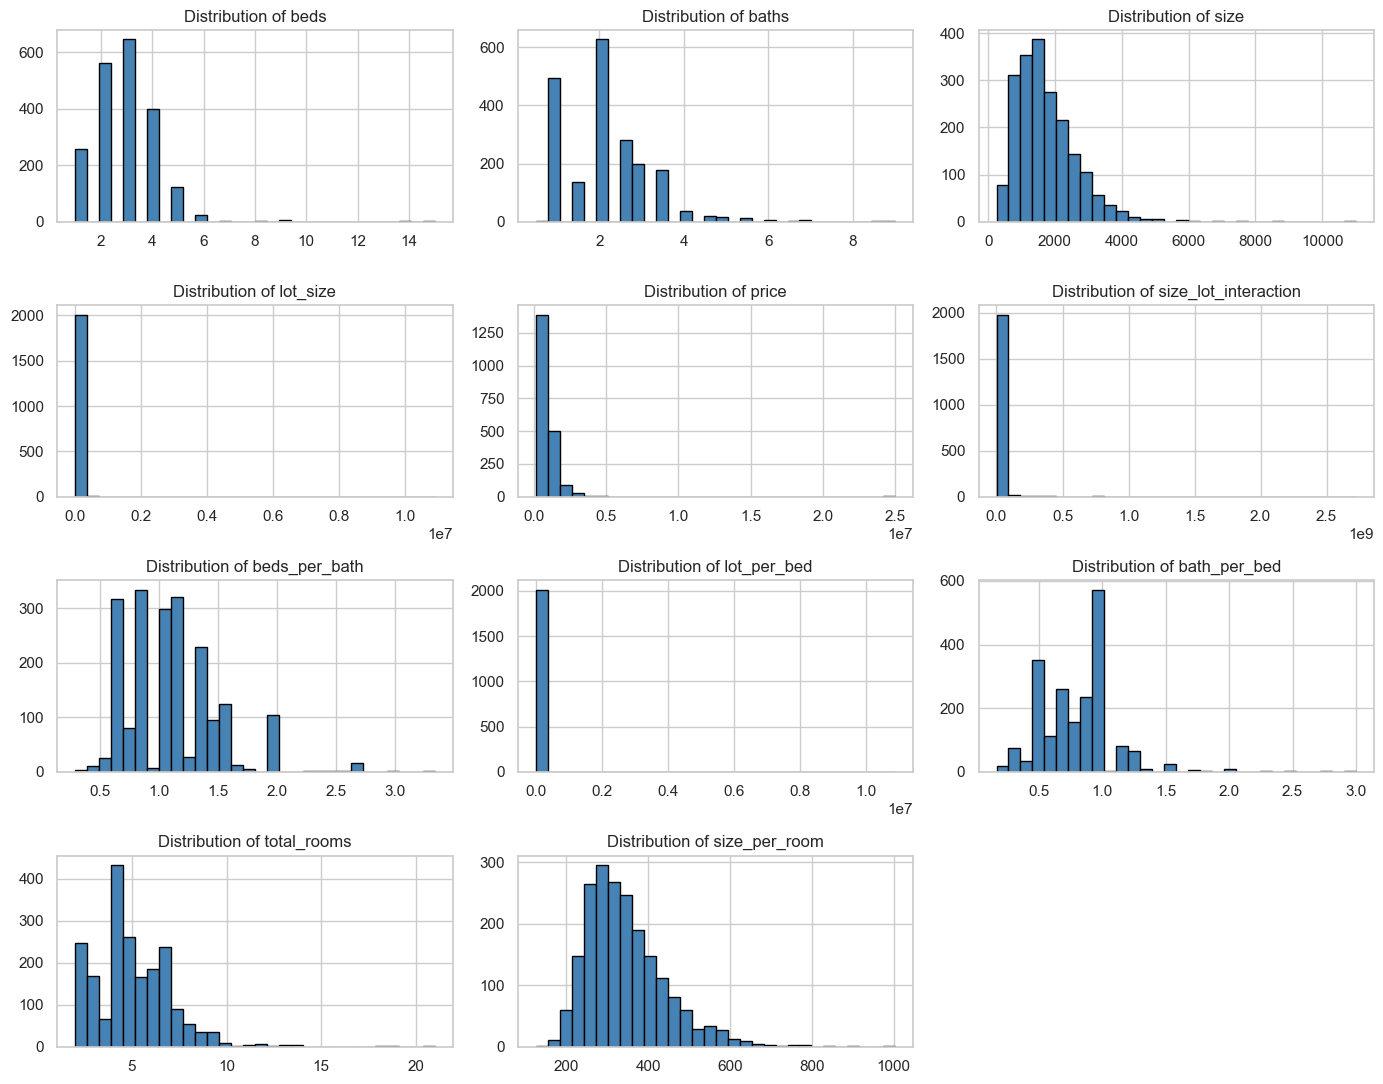

In [5]:
skewness=df_train[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed_features=skewness[skewness.abs()>0.75].sort_values(ascending=False)
print('Skewed features with |skew| > 0.75:')
display(skewed_features)
fig,axes=plt.subplots(int(np.ceil(len(numeric_cols)/3)),3,figsize=(14,11)); axes=axes.flatten()
for i,col in enumerate(numeric_cols):
    axes[i].hist(df_train[col],bins=30,color='steelblue',edgecolor='black'); axes[i].set_title(f'Distribution of {col}')
for j in range(i+1,len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

**Interpretation and next decision:** skewed predictors will be log-transformed for linear models. Random Forest will use raw values because tree models do not require normally distributed inputs.

### 4.2 Log-Transformed Predictors

These plots confirm whether `log1p` compresses extreme values. Better-shaped predictors improve linear-model stability and make regularization more effective.

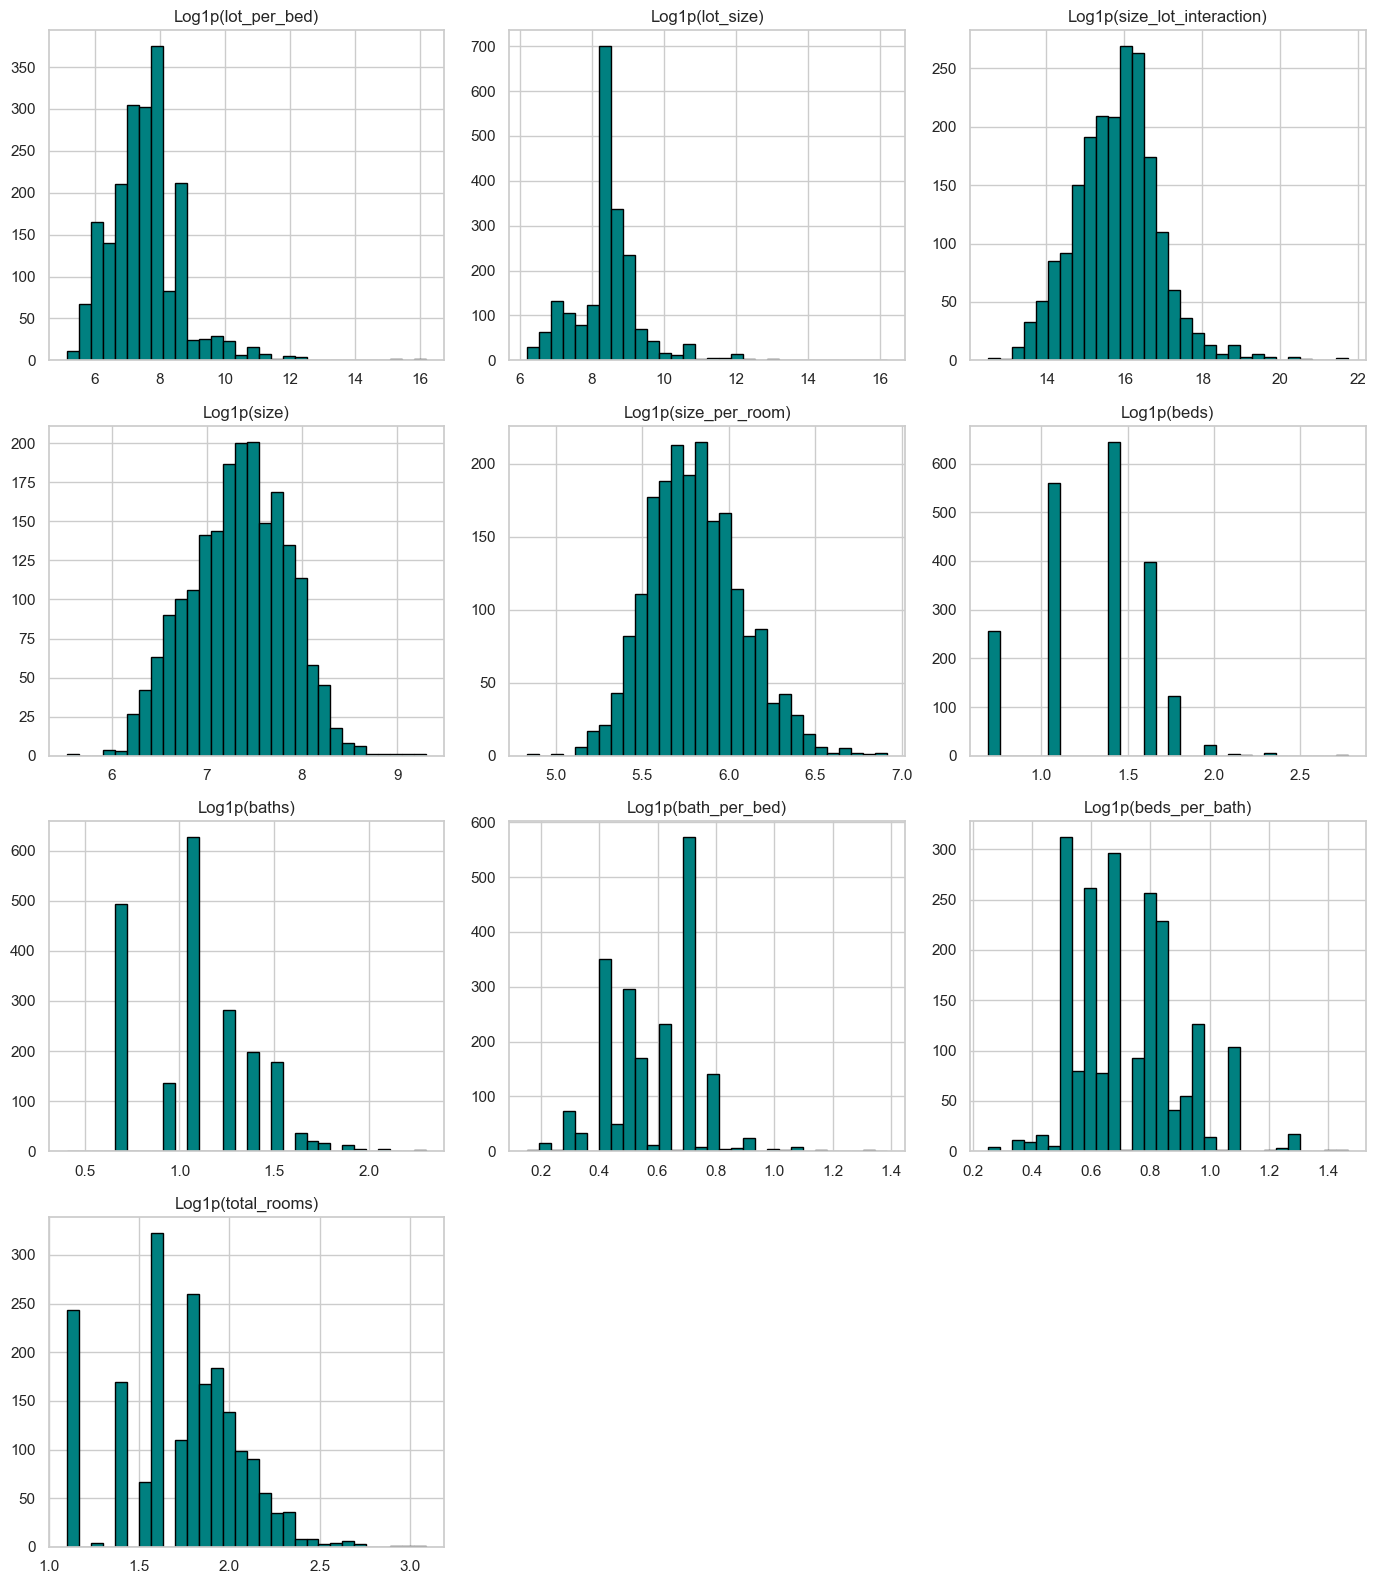

In [6]:
skewed_non_target=[c for c in skewed_features.index if c!='price']
if skewed_non_target:
    fig,axes=plt.subplots(int(np.ceil(len(skewed_non_target)/3)),3,figsize=(14,4*int(np.ceil(len(skewed_non_target)/3))))
    axes=np.array(axes).flatten()
    for i,col in enumerate(skewed_non_target):
        axes[i].hist(np.log1p(df_train[col]),bins=30,color='teal',edgecolor='black'); axes[i].set_title(f'Log1p({col})')
    for j in range(i+1,len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(); plt.show()

### 4.3 Correlation Heatmap

The heatmap shows linear relationships between numeric variables. Size-related variables are related to price, and several predictors are correlated with each other.

**Decision impact:** multicollinearity motivates Ridge, Lasso, and Elastic Net rather than relying only on ordinary linear regression.

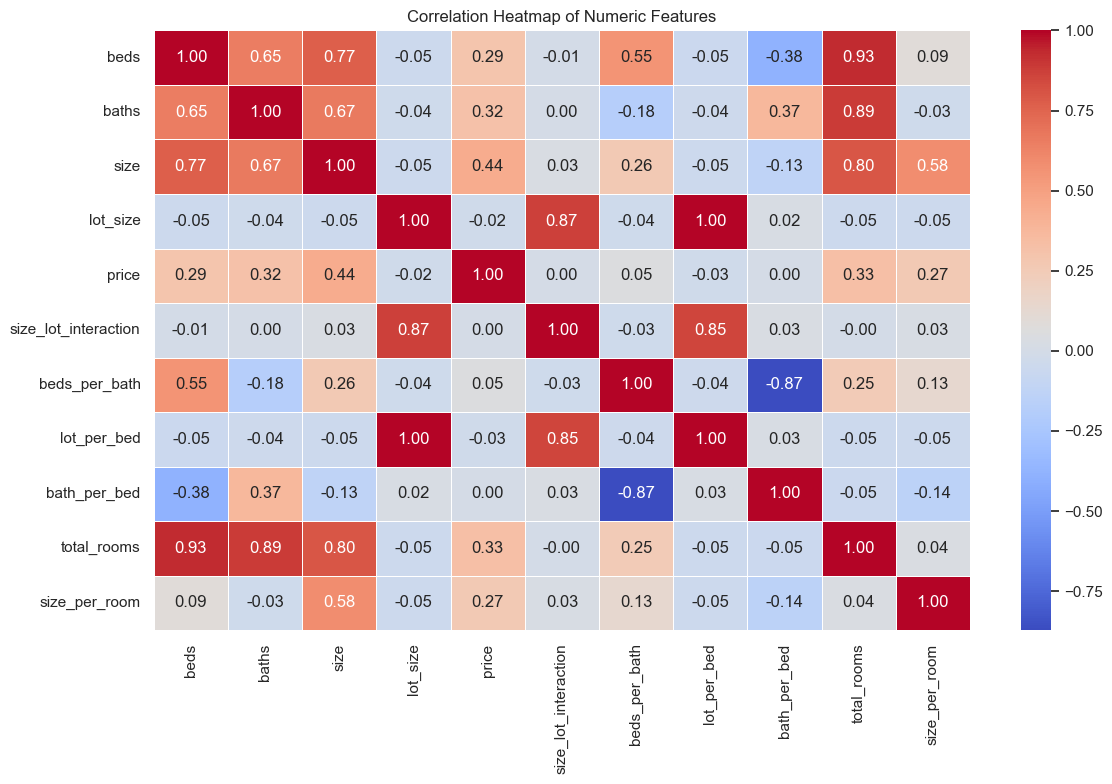

In [7]:
plt.figure(figsize=(12,8))
corr=df_train[numeric_cols].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout(); plt.show()

### 4.4 Price Relationships

Boxplots show how price varies across bedroom and bathroom counts. Scatter plots show whether key continuous predictors have linear or non-linear relationships with price.

**Decision impact:** visible spread and non-linearity justify comparing linear models with Random Forest.

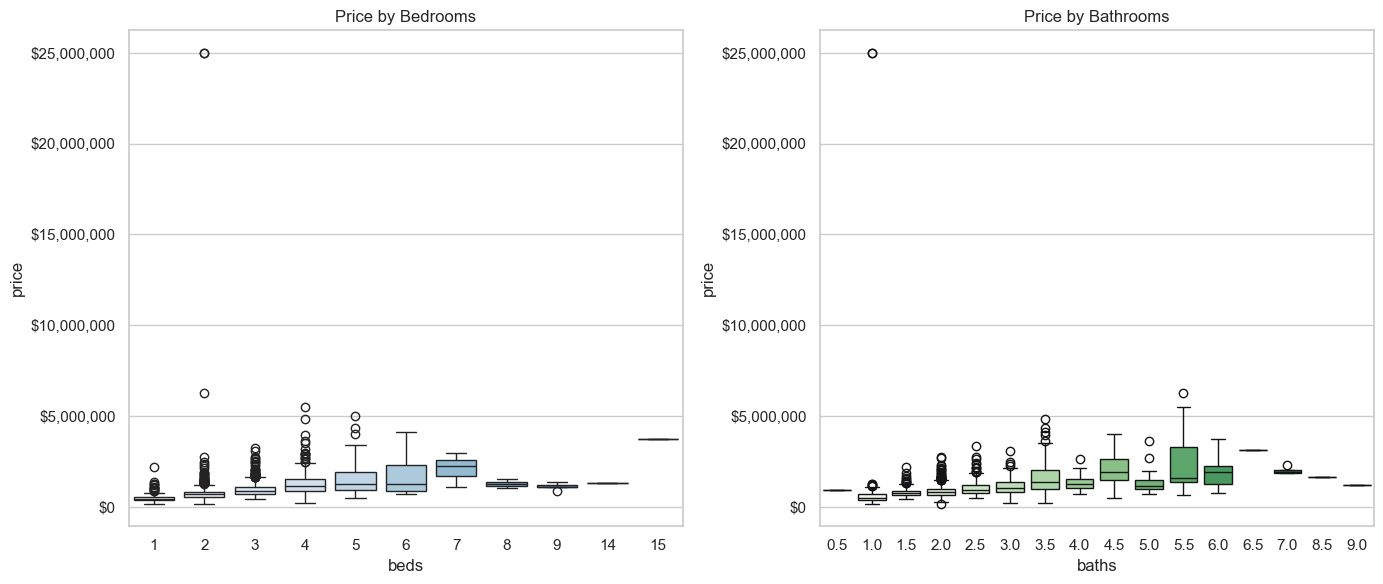

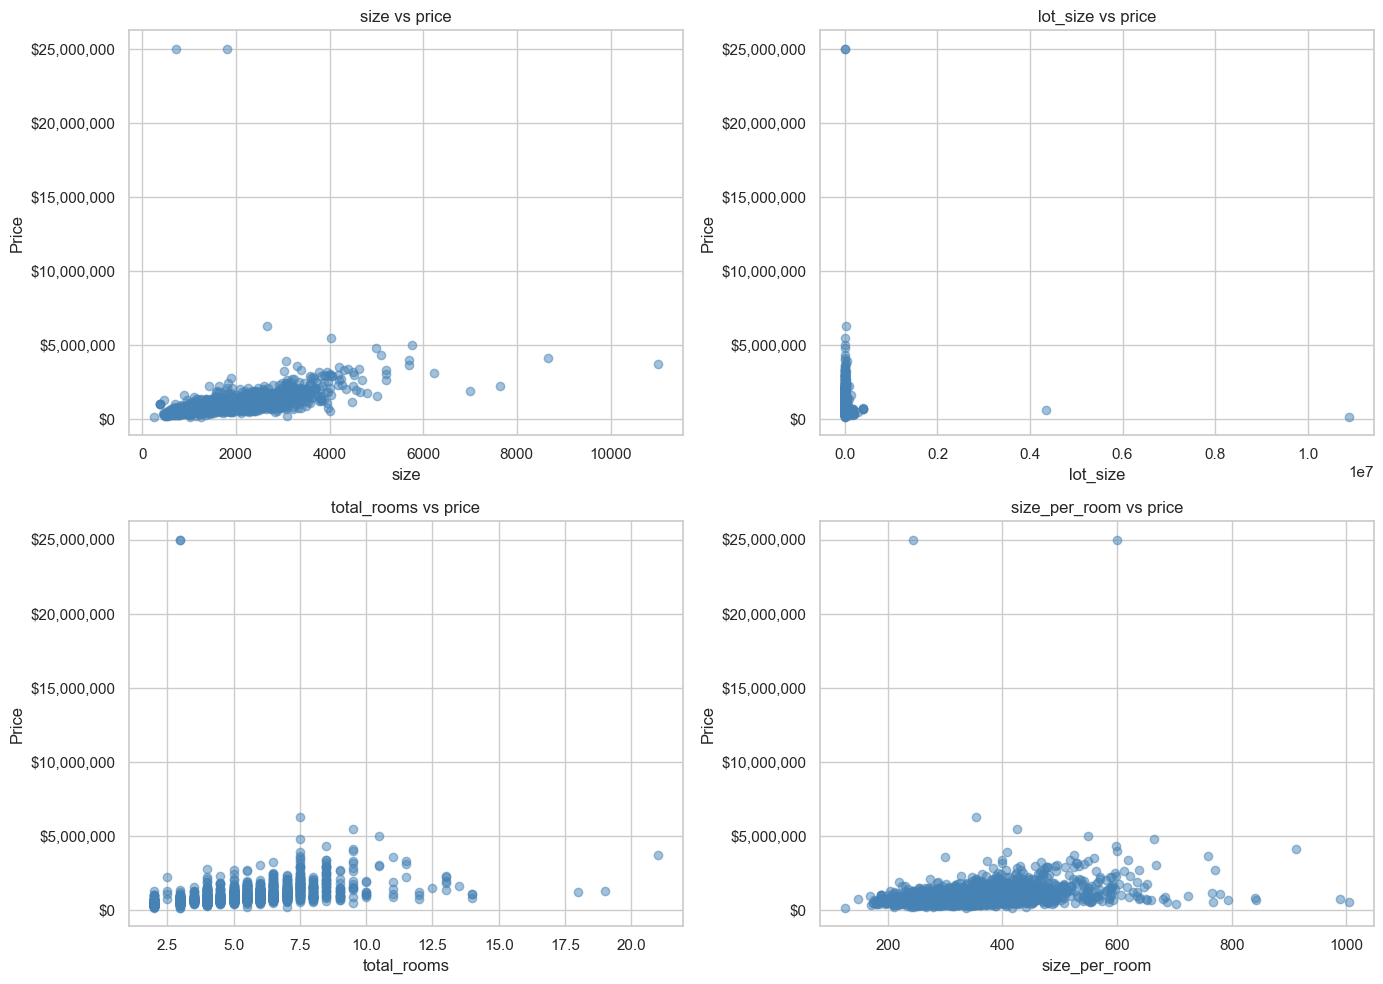

In [8]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.boxplot(x='beds',y='price',data=df_train,ax=axes[0],hue='beds',palette='Blues',legend=False); axes[0].set_title('Price by Bedrooms'); axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
sns.boxplot(x='baths',y='price',data=df_train,ax=axes[1],hue='baths',palette='Greens',legend=False); axes[1].set_title('Price by Bathrooms'); axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(2,2,figsize=(14,10)); axes=axes.flatten()
for i,col in enumerate(['size','lot_size','total_rooms','size_per_room']):
    axes[i].scatter(df_train[col],df_train['price'],alpha=0.5,color='steelblue'); axes[i].set_title(f'{col} vs price'); axes[i].set_xlabel(col); axes[i].set_ylabel('Price'); axes[i].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout(); plt.show()

### 4.5 Statistical Signal Checks

Visual patterns are checked statistically.

- **Pearson correlation:** linear relationship with price.
- **Spearman correlation:** monotonic relationship with price, useful for skewed and non-linear data.

**Decision impact:** statistically meaningful predictors are retained for modeling.

In [9]:
stat_features=['beds','baths','size','lot_size','total_rooms','size_per_room']
rows=[]
for col in stat_features:
    pr,pp=stats.pearsonr(df_train[col],df_train['price'])
    sr,sp=stats.spearmanr(df_train[col],df_train['price'])
    rows.append({'Feature':col,'Pearson r':pr,'Pearson p-value':pp,'Spearman rho':sr,'Spearman p-value':sp})
correlation_tests=pd.DataFrame(rows).sort_values('Spearman rho',key=lambda s:s.abs(),ascending=False).reset_index(drop=True)
display(correlation_tests)

,Feature,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,size,0.444140,3.221636e-98,0.776161,0.000000e+00
1,total_rooms,0.334057,9.462020e-54,0.690119,3.607297e-285
2,beds,0.293516,2.400661e-41,0.639216,5.375139e-232
3,baths,0.317325,2.142113e-48,0.629875,2.610641e-223
4,size_per_room,0.268264,1.430840e-34,0.378202,1.458411e-69
5,lot_size,-0.024796,2.657842e-01,-0.050911,2.225582e-02


**Interpretation and next decision:** size has the strongest monotonic relationship with price. Bedrooms, bathrooms, and total rooms also show meaningful signal. Lot size alone is weaker, so location and context must be included.

## 5. ZIP Code Analysis

Location is central in real estate. ZIP code is tested instead of being dropped.

**Plot purpose:** compare mean price by ZIP code.

**Statistical test:** Kruskal-Wallis H-test checks whether ZIP-code groups have significantly different price distributions. It is appropriate because prices are skewed and ZIP groups have different sample sizes.

**Decision impact:** a significant result justifies retaining ZIP code through leakage-aware target encoding.

,mean,median,count
zip_code,,,
98105,2.012199e+06,1200000.0,73
98112,1.636133e+06,1400000.0,57
98199,1.197310e+06,1085250.0,72
98102,1.178258e+06,763750.0,60
98177,1.157941e+06,995000.0,27
98119,1.048173e+06,937500.0,70
98136,1.020102e+06,887500.0,60
98115,1.016978e+06,909000.0,170
98109,1.012418e+06,850000.0,61


Number of unique ZIP codes: 28


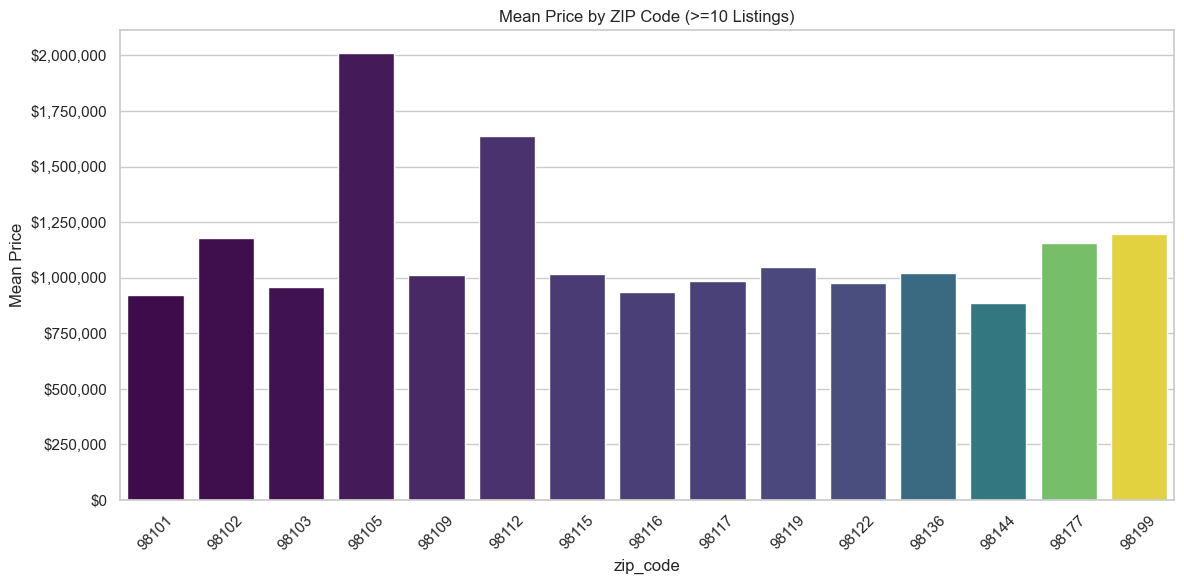

Kruskal-Wallis H-test across ZIP codes: H=336.49, p-value=9.91e-56
Effect size (epsilon-squared): 0.156


In [10]:
zip_stats=df_train.groupby('zip_code')['price'].agg(['mean','median','count']).sort_values('mean',ascending=False)
display(zip_stats.head(10)); print('Number of unique ZIP codes:',df_train['zip_code'].nunique())
top_zips=zip_stats[zip_stats['count']>=10].head(15).index
plt.figure(figsize=(12,6)); sns.barplot(x=top_zips,y=df_train.groupby('zip_code')['price'].mean().loc[top_zips],hue=top_zips,palette='viridis',legend=False)
plt.xticks(rotation=45); plt.title('Mean Price by ZIP Code (>=10 Listings)'); plt.ylabel('Mean Price'); plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}')); plt.tight_layout(); plt.show()
zip_groups=[g['price'].values for _,g in df_train.groupby('zip_code') if len(g)>=10]
kw_stat,kw_p=stats.kruskal(*zip_groups); n_obs=sum(len(g) for g in zip_groups); k_groups=len(zip_groups); epsilon_sq=(kw_stat-k_groups+1)/(n_obs-k_groups)
print(f'Kruskal-Wallis H-test across ZIP codes: H={kw_stat:.2f}, p-value={kw_p:.2e}')
print(f'Effect size (epsilon-squared): {epsilon_sq:.3f}')

## 6. Leakage-Aware Data Preparation

Target encoding uses `price`, so it must be handled carefully.

**Decision:** split train/validation before encoding ZIP code.

Training rows receive out-of-fold smoothed encodings. Validation and test rows use maps learned only from the training fold. This prevents validation/test prices from leaking into model features.

In [11]:
base_feature_cols=['beds','baths','size','lot_size','size_lot_interaction','beds_per_bath','lot_per_bed','bath_per_bed','total_rooms','size_per_room']
target_col='price'
train_model_df,val_model_df=train_test_split(df_train,test_size=0.2,random_state=RANDOM_STATE)
train_model_df=train_model_df.copy(); val_model_df=val_model_df.copy(); df_test=df_test.copy()
def build_smoothed_target_map(frame,zip_col='zip_code',target_col='price',smoothing=10):
    prior=frame[target_col].mean(); s=frame.groupby(zip_col)[target_col].agg(['mean','count'])
    return ((s['count']*s['mean']+smoothing*prior)/(s['count']+smoothing)), prior
def make_oof_target_encoding(train_frame,apply_frames,n_splits=5,smoothing=10):
    oof=pd.Series(index=train_frame.index,dtype=float); kf=KFold(n_splits=n_splits,shuffle=True,random_state=RANDOM_STATE)
    for fit_idx,hold_idx in kf.split(train_frame):
        fit=train_frame.iloc[fit_idx]; hold=train_frame.iloc[hold_idx]; m,p=build_smoothed_target_map(fit,smoothing=smoothing)
        oof.loc[hold.index]=hold['zip_code'].map(m).fillna(p)
    final_map,final_prior=build_smoothed_target_map(train_frame,smoothing=smoothing)
    return oof,[f['zip_code'].map(final_map).fillna(final_prior) for f in apply_frames],final_map,final_prior
train_zip_enc,(val_zip_enc,test_zip_enc),zip_target_mean,global_price_mean=make_oof_target_encoding(train_model_df,[val_model_df,df_test])
train_model_df['zip_target_enc']=train_zip_enc; val_model_df['zip_target_enc']=val_zip_enc; df_test['zip_target_enc']=test_zip_enc
feature_cols=base_feature_cols+['zip_target_enc']
X_train=train_model_df[feature_cols]; y_train=train_model_df[target_col]
X_val=val_model_df[feature_cols]; y_val=val_model_df[target_col]
skewed_predictors=X_train[base_feature_cols].apply(lambda x: skew(x.dropna())).pipe(lambda s:s[s.abs()>0.75].index.tolist())
X_train_rf=X_train.copy(); X_val_rf=X_val.copy(); X_test_rf=df_test[feature_cols].copy()
X_train_lr=X_train.copy(); X_val_lr=X_val.copy(); X_test_lr=df_test[feature_cols].copy()
for col in skewed_predictors:
    X_train_lr[col]=np.log1p(X_train_lr[col]); X_val_lr[col]=np.log1p(X_val_lr[col]); X_test_lr[col]=np.log1p(X_test_lr[col])
y_train_lr=np.log1p(y_train)
scaler=StandardScaler(); X_train_lr_scaled=scaler.fit_transform(X_train_lr); X_val_lr_scaled=scaler.transform(X_val_lr); X_test_lr_scaled=scaler.transform(X_test_lr)
print('Feature count:',len(feature_cols)); print('Skewed predictors log-transformed:',skewed_predictors); print('Unseen ZIPs in validation:',(~val_model_df['zip_code'].isin(zip_target_mean.index)).sum()); print('Unseen ZIPs in test:',(~df_test['zip_code'].isin(zip_target_mean.index)).sum())

Feature count: 11
Skewed predictors log-transformed: ['beds', 'baths', 'size', 'lot_size', 'size_lot_interaction', 'beds_per_bath', 'lot_per_bed', 'bath_per_bed', 'total_rooms', 'size_per_room']
Unseen ZIPs in validation: 0
Unseen ZIPs in test: 1


## 7. Model Training and Validation Comparison

Models are compared against a median baseline. Linear models provide interpretability; regularized models handle correlated features; Random Forest captures non-linear interactions. Validation RMSE is used for model selection.

In [12]:
def regression_metrics(y_true,y_pred):
    return {'RMSE':np.sqrt(mean_squared_error(y_true,y_pred)),'MAE':mean_absolute_error(y_true,y_pred),'R2':r2_score(y_true,y_pred)}
validation_predictions={}; test_predictions={}
baseline=DummyRegressor(strategy='median').fit(X_train_rf,y_train); validation_predictions['Baseline Median']=baseline.predict(X_val_rf); test_predictions['Baseline Median']=baseline.predict(X_test_rf)
lr=LinearRegression().fit(X_train_lr_scaled,y_train_lr); validation_predictions['Linear Regression']=np.expm1(lr.predict(X_val_lr_scaled)); test_predictions['Linear Regression']=np.expm1(lr.predict(X_test_lr_scaled))
ridge=RidgeCV(alphas=np.logspace(-3,2,50),cv=5).fit(X_train_lr_scaled,y_train_lr); validation_predictions['Ridge']=np.expm1(ridge.predict(X_val_lr_scaled)); test_predictions['Ridge']=np.expm1(ridge.predict(X_test_lr_scaled))
lasso=LassoCV(alphas=np.logspace(-4,1,50),cv=5,random_state=RANDOM_STATE,max_iter=10000).fit(X_train_lr_scaled,y_train_lr); validation_predictions['Lasso']=np.expm1(lasso.predict(X_val_lr_scaled)); test_predictions['Lasso']=np.expm1(lasso.predict(X_test_lr_scaled))
enet=ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9],cv=5,random_state=RANDOM_STATE,max_iter=10000).fit(X_train_lr_scaled,y_train_lr); validation_predictions['Elastic Net']=np.expm1(enet.predict(X_val_lr_scaled)); test_predictions['Elastic Net']=np.expm1(enet.predict(X_test_lr_scaled))
rf_grid=GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=1),{'n_estimators':[100,200],'max_depth':[10,15,None],'min_samples_split':[2,5]},cv=3,scoring='neg_root_mean_squared_error',n_jobs=1).fit(X_train_rf,y_train)
best_rf=rf_grid.best_estimator_; validation_predictions['Random Forest']=best_rf.predict(X_val_rf); test_predictions['Random Forest']=best_rf.predict(X_test_rf)
validation_results=pd.DataFrame([{'Model':n,**regression_metrics(y_val,p)} for n,p in validation_predictions.items()]).sort_values('RMSE').reset_index(drop=True)
display(validation_results)
print('Ridge alpha:',ridge.alpha_); print('Lasso alpha:',lasso.alpha_); print('Elastic Net alpha:',enet.alpha_,'l1_ratio:',enet.l1_ratio_); print('Random Forest best params:',rf_grid.best_params_)

,Model,RMSE,MAE,R2
0,Random Forest,387132.671173,202397.121594,0.545559
1,Ridge,402712.712990,212548.005033,0.508246
2,Lasso,402791.961158,212786.339163,0.508052
3,Elastic Net,403026.687577,212544.538126,0.507479
4,Linear Regression,408242.559133,212965.790020,0.494648
5,Baseline Median,584416.107479,356457.497525,-0.035623


Ridge alpha: 0.9102981779915218
Lasso alpha: 0.0001
Elastic Net alpha: 0.0007828256219686413 l1_ratio: 0.5
Random Forest best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


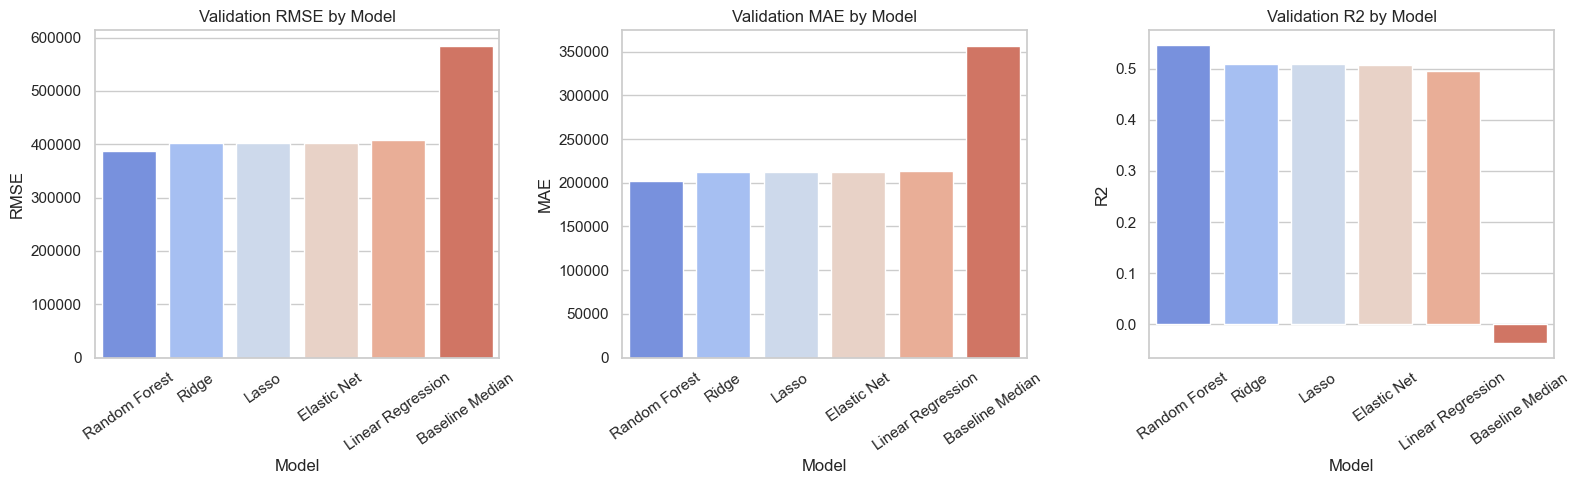

In [13]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,metric in zip(axes,['RMSE','MAE','R2']):
    sns.barplot(data=validation_results,x='Model',y=metric,ax=ax,hue='Model',palette='coolwarm',legend=False); ax.set_title(f'Validation {metric} by Model'); ax.tick_params(axis='x',rotation=35)
plt.tight_layout(); plt.show()

**Interpretation and next decision:** all trained models beat the baseline, showing useful predictive signal. Random Forest leads validation performance, so it is used for residual diagnostics and checked again on the held-out test set.

## 8. Residual Diagnostics

Residual plots show where the model fails. The residual mean t-test checks bias, the normality test checks distributional assumptions, and the Spearman test checks whether error grows with predicted price.

Best validation model: Random Forest


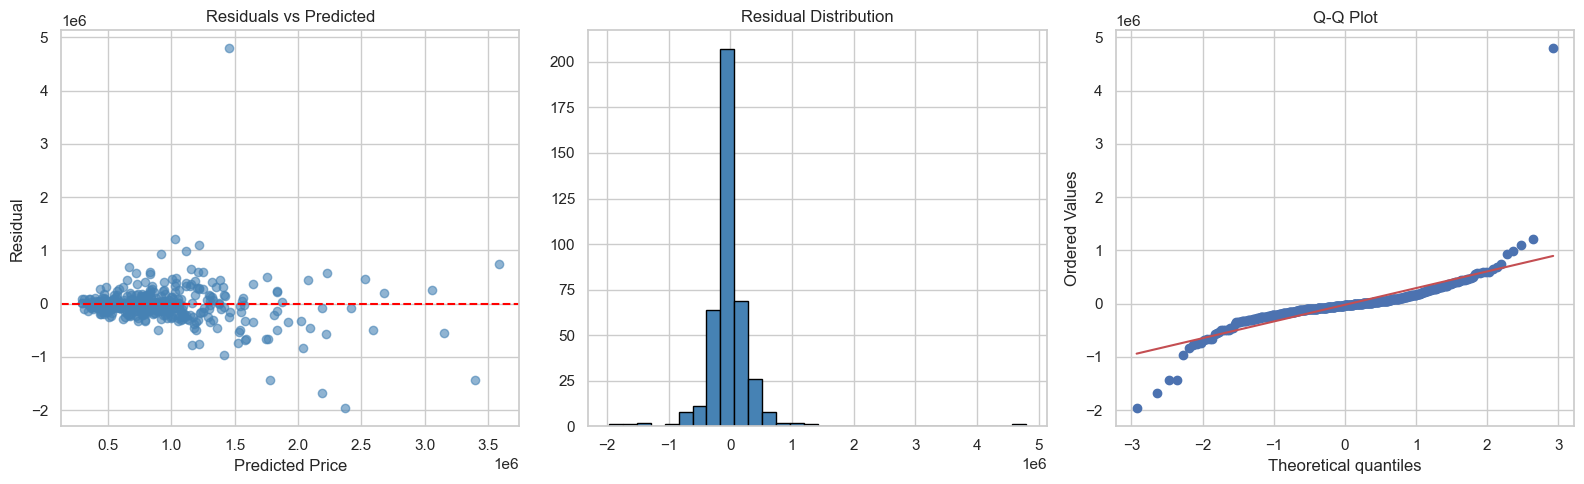

Mean residual: -21017.90
Residual mean t-test: t=-1.091, p-value=0.276
Residual normality test: statistic=430.860, p-value=2.753e-94
Absolute residual vs prediction Spearman test: rho=0.487, p-value=2.083e-25


In [14]:
best_model_name=validation_results.iloc[0]['Model']; best_val_pred=validation_predictions[best_model_name]; residuals=y_val-best_val_pred
print('Best validation model:',best_model_name)
fig,axes=plt.subplots(1,3,figsize=(16,5))
axes[0].scatter(best_val_pred,residuals,alpha=0.6,color='steelblue'); axes[0].axhline(0,color='red',linestyle='--'); axes[0].set_title('Residuals vs Predicted'); axes[0].set_xlabel('Predicted Price'); axes[0].set_ylabel('Residual')
axes[1].hist(residuals,bins=30,color='steelblue',edgecolor='black'); axes[1].set_title('Residual Distribution')
stats.probplot(residuals,dist='norm',plot=axes[2]); axes[2].set_title('Q-Q Plot')
plt.tight_layout(); plt.show()
residual_mean_test=stats.ttest_1samp(residuals,popmean=0); normality_test=stats.normaltest(residuals); hetero_signal=stats.spearmanr(best_val_pred,np.abs(residuals))
print(f'Mean residual: {residuals.mean():.2f}')
print(f'Residual mean t-test: t={residual_mean_test.statistic:.3f}, p-value={residual_mean_test.pvalue:.3f}')
print(f'Residual normality test: statistic={normality_test.statistic:.3f}, p-value={normality_test.pvalue:.3e}')
print(f'Absolute residual vs prediction Spearman test: rho={hetero_signal.statistic:.3f}, p-value={hetero_signal.pvalue:.3e}')

**Interpretation and next decision:** residuals are not perfectly normal and errors tend to grow for higher-priced homes. Future improvement should focus on richer features for premium properties, such as condition, renovation history, view, school district, and sale date.

## 9. Feature Importance

Feature importance checks whether the model story is credible. Size and location should matter in a real-estate model; suspicious importance patterns would indicate a pipeline issue.

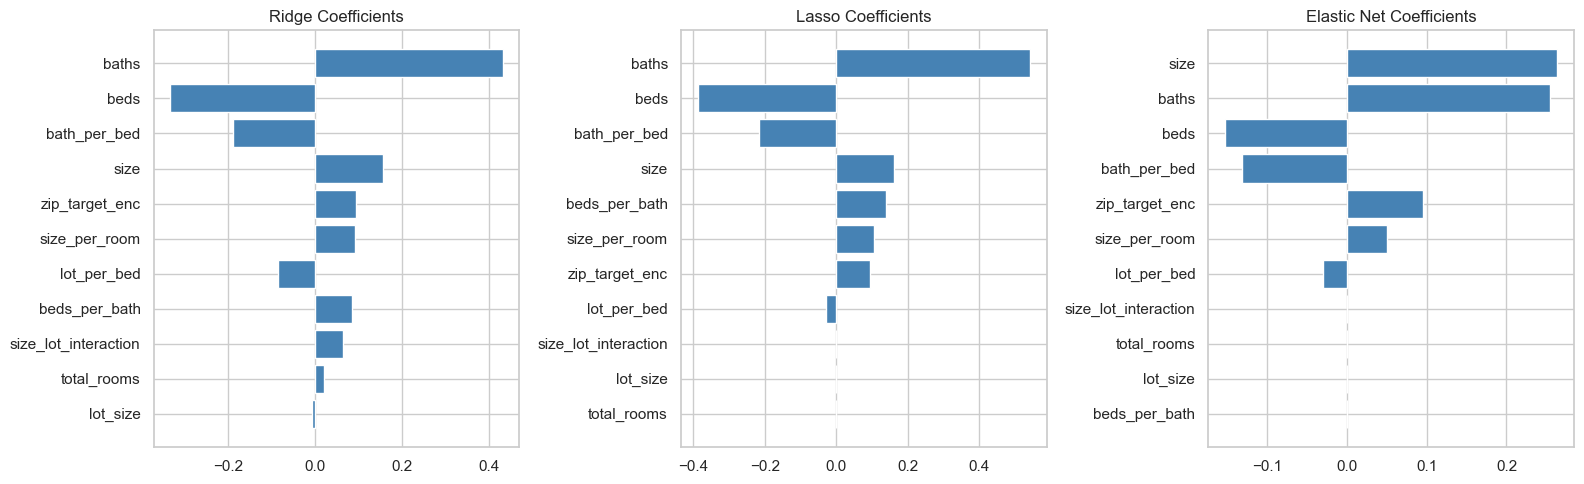

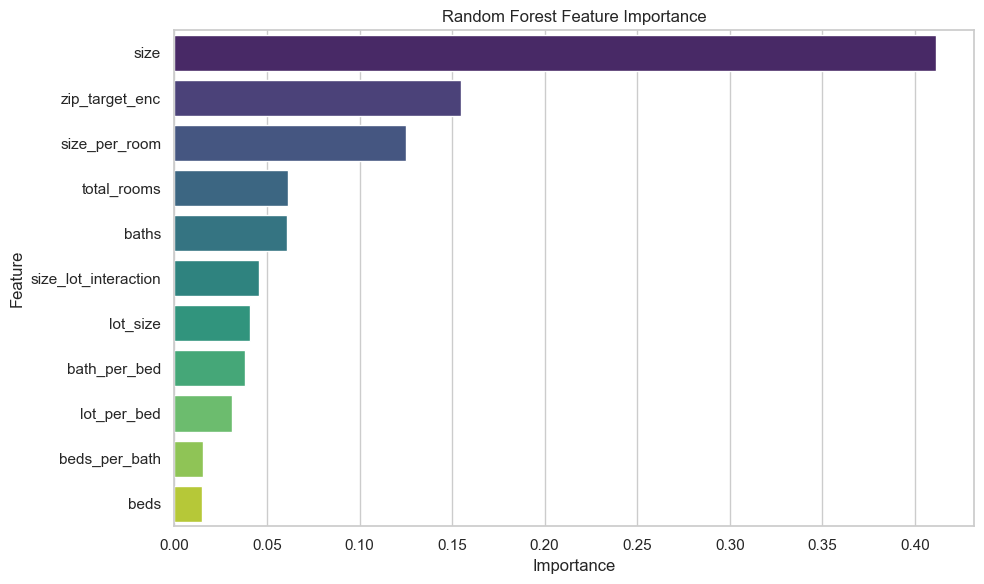

,Feature,Importance
2,size,0.411333
10,zip_target_enc,0.154863
9,size_per_room,0.125301
8,total_rooms,0.061208
1,baths,0.060771
4,size_lot_interaction,0.045601
3,lot_size,0.041005
7,bath_per_bed,0.038376
6,lot_per_bed,0.031275
5,beds_per_bath,0.015196


In [15]:
linear_importance=pd.DataFrame({'Feature':feature_cols,'Ridge_Coef':ridge.coef_,'Lasso_Coef':lasso.coef_,'ElasticNet_Coef':enet.coef_}).assign(Ridge_abs=lambda d:d['Ridge_Coef'].abs()).sort_values('Ridge_abs',ascending=False)
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,col,title in zip(axes,['Ridge_Coef','Lasso_Coef','ElasticNet_Coef'],['Ridge','Lasso','Elastic Net']):
    d=linear_importance.sort_values(col,key=abs,ascending=True); ax.barh(d['Feature'],d[col],color='steelblue'); ax.set_title(f'{title} Coefficients')
plt.tight_layout(); plt.show()
rf_importance=pd.DataFrame({'Feature':feature_cols,'Importance':best_rf.feature_importances_}).sort_values('Importance',ascending=False)
plt.figure(figsize=(10,6)); sns.barplot(data=rf_importance,x='Importance',y='Feature',hue='Feature',palette='viridis',legend=False); plt.title('Random Forest Feature Importance'); plt.tight_layout(); plt.show(); display(rf_importance)

## 10. Held-Out Test Evaluation and Prediction Export

The test set is used only after validation. This estimates performance on unseen data and exports predictions for review.

In [16]:
y_test=df_test['price']
test_results=pd.DataFrame([{'Model':n,**regression_metrics(y_test,p)} for n,p in test_predictions.items()]).sort_values('RMSE').reset_index(drop=True)
display(test_results)
prediction_output=df_test_raw.copy()
prediction_output['pred_baseline_median']=np.round(test_predictions['Baseline Median'],1)
prediction_output['pred_linear']=np.round(test_predictions['Linear Regression'],1)
prediction_output['pred_ridge']=np.round(test_predictions['Ridge'],1)
prediction_output['pred_lasso']=np.round(test_predictions['Lasso'],1)
prediction_output['pred_elasticnet']=np.round(test_predictions['Elastic Net'],1)
prediction_output['pred_rf']=np.round(test_predictions['Random Forest'],1)
prediction_output.to_csv('test_predictions_all_models.csv',index=False)
print('Saved test_predictions_all_models.csv with',len(prediction_output),'rows.')

,Model,RMSE,MAE,R2
0,Random Forest,418156.650585,230906.463855,0.526792
1,Linear Regression,420119.912667,237952.926975,0.522338
2,Lasso,422451.148410,238783.725596,0.517022
3,Ridge,422798.469702,238697.069691,0.516228
4,Elastic Net,423790.054814,238828.098498,0.513956
5,Baseline Median,630749.932730,386229.293069,-0.076685


Saved test_predictions_all_models.csv with 505 rows.


## 11. Model Uncertainty and Paired Error Testing

Point metrics do not show uncertainty. Bootstrap RMSE intervals estimate how much RMSE could vary if the test set were resampled. Paired Wilcoxon signed-rank tests compare absolute errors row-by-row between the selected model and alternatives.

In [17]:
rng=np.random.default_rng(RANDOM_STATE); n_bootstraps=2000; y_test_array=y_test.to_numpy(); ci_rows=[]
for model_name,pred in test_predictions.items():
    pred_array=np.asarray(pred); boot=[]
    for _ in range(n_bootstraps):
        idx=rng.integers(0,len(y_test_array),len(y_test_array)); boot.append(np.sqrt(mean_squared_error(y_test_array[idx],pred_array[idx])))
    ci_rows.append({'Model':model_name,'RMSE':np.sqrt(mean_squared_error(y_test_array,pred_array)),'RMSE CI Lower':np.percentile(boot,2.5),'RMSE CI Upper':np.percentile(boot,97.5)})
rmse_uncertainty=pd.DataFrame(ci_rows).sort_values('RMSE').reset_index(drop=True); display(rmse_uncertainty)
best_test_model=test_results.iloc[0]['Model']; best_abs_error=np.abs(y_test_array-np.asarray(test_predictions[best_test_model])); paired=[]
for model_name,pred in test_predictions.items():
    if model_name==best_test_model: continue
    comp_abs_error=np.abs(y_test_array-np.asarray(pred)); res=stats.wilcoxon(best_abs_error,comp_abs_error,alternative='less',zero_method='wilcox')
    paired.append({'Comparison':f'{best_test_model} absolute error < {model_name} absolute error','Wilcoxon statistic':res.statistic,'p-value':res.pvalue})
paired_error_tests=pd.DataFrame(paired).sort_values('p-value').reset_index(drop=True); display(paired_error_tests)

,Model,RMSE,RMSE CI Lower,RMSE CI Upper
0,Random Forest,418156.650585,331391.841807,512430.072251
1,Linear Regression,420119.912667,323166.797299,544377.059141
2,Lasso,422451.148410,324552.700117,540012.681457
3,Ridge,422798.469702,325004.331711,539172.684495
4,Elastic Net,423790.054814,323891.507674,557496.140908
5,Baseline Median,630749.932730,523829.559480,752977.443816


,Comparison,Wilcoxon statistic,p-value
0,Random Forest absolute error < Baseline Median...,31400.0,2.070326e-23
1,Random Forest absolute error < Linear Regressi...,56442.5,1.167432e-02
2,Random Forest absolute error < Lasso absolute ...,56844.5,1.597029e-02
3,Random Forest absolute error < Ridge absolute ...,57086.5,1.916105e-02
4,Random Forest absolute error < Elastic Net abs...,57093.5,1.926088e-02


## 12. Summary and Conclusions

The final workflow demonstrates data quality control, leakage prevention, statistical validation, model comparison, residual diagnostics, uncertainty testing, and reproducible prediction export.

**Main findings:** ZIP code is statistically meaningful, size-related variables are central predictors, all trained models beat the median baseline, and Random Forest has the strongest validation and held-out test performance.

**Caveat:** high-priced properties have larger absolute errors. A production model would benefit from condition, renovation, view, school district, sale date, and richer location features.